# Capacitance calibration — round one

All capacitances are in **pF**. Fit the equally weighted reference means with
$C_\mathrm{measured} = m C_\mathrm{nominal} + b$, then infer each device's nominal
capacitance using $(\overline{C}_\mathrm{measured} - b)/m$.

Raw data are preserved below. The final **12.03 pF** entry in the 10 pF reference
row is excluded from the analysis as the identified duplicate, leaving five
measurements per reference and device. Gen3 has d1 and d2 only.

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.linewidth": 1.2,
    "axes.grid": True,
    "axes.grid.axis": "both",
    "axes.grid.which": "major",
    "axes.axisbelow": True,
    "grid.color": "0.88",
    "grid.linewidth": 0.6,
    "grid.linestyle": "-",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,
    "figure.dpi": 120,
})


In [32]:
# Raw capacitance measurements (pF); values preserved.
round_one_nominal_cap = np.array([4.7, 7.5, 10, 15, 27])
round_one_measured_cap = np.array([
    [5.41, 5.68, 5.73, 6.43, 6.48],
    [7.79, 8.88, 8.40, 8.88, 8.39],
    [11.75, 12.42, 13.60, 9.34, 10.23, 12.03],
    [15.99, 15.68, 16.05, 16.24, 15.72],
    [28.44, 28.44, 28.52, 28.59, 27.75]
], dtype=object)
round_one_gen3_d1 = np.array([21.56, 21.90, 21.80, 21.68,21.36])
round_one_gen3_d2 = np.array([21.58, 21.67, 22.09, 21.69,22.03])
round_one_gen2_d1 = np.array([5.93, 6.20, 6.29, 5.83, 6.04])
round_one_gen2_d2 = np.array([6.34, 5.33, 6.42, 6.84, 5.82])
round_one_gen2_d3 = np.array([5.53, 6.75, 6.81, 6.88, 6.53])

# 2nd round
round_two_nominal_cap = np.array([4.7, 10, 15, 18, 24])
round_two_measured_cap = np.array([4.67, 9.94, 15.51, 18.64, 24.62])
round_two_gen3 = np.array([20.44])
round_two_gen2 = np.array([3.72])

## Calibration

Each reference contributes one mean to an ordinary least-squares linear fit.
Error bars show ±1 sample standard deviation (SD) of the five measurements.

In [33]:
calibration_repeats = [np.asarray(row, dtype=float) for row in round_one_measured_cap]
calibration_repeats[2] = calibration_repeats[2][:-1]  # Exclude duplicate 12.03 pF.
calibration_mean = np.array([row.mean() for row in calibration_repeats])
calibration_sd = np.array([row.std(ddof=1) for row in calibration_repeats])

calibration_slope, calibration_offset = np.polyfit(round_one_nominal_cap, calibration_mean, 1)
calibration_fit = calibration_slope * round_one_nominal_cap + calibration_offset
calibration_r2 = 1 - np.sum((calibration_mean - calibration_fit)**2) / np.sum(
    (calibration_mean - calibration_mean.mean())**2
)


def nominal_from_measured(measured):
    return (np.asarray(measured) - calibration_offset) / calibration_slope


calibration_summary = pd.DataFrame({
    "Nominal (pF)": round_one_nominal_cap,
    "n": [len(row) for row in calibration_repeats],
    "Measured mean (pF)": calibration_mean,
    "Measured SD (pF)": calibration_sd,
})
display(calibration_summary.style.hide(axis="index").format(precision=3))
print(f"Measured = {calibration_slope:.6f} × nominal + {calibration_offset:.6f} pF")
print(f"R² = {calibration_r2:.6f}")

Nominal (pF),n,Measured mean (pF),Measured SD (pF)
4.700,5,5.946,0.481
7.500,5,8.468,0.450
10.000,5,11.468,1.702
15.000,5,15.936,0.235
27.000,5,28.348,0.340


Measured = 1.005288 × nominal + 1.125302 pF
R² = 0.999324


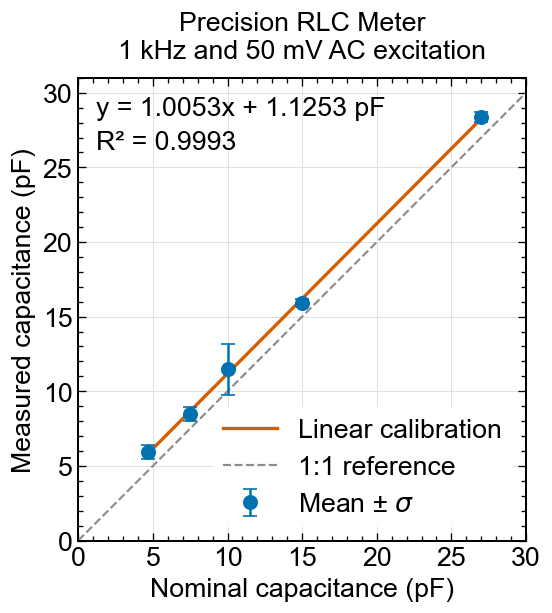

In [34]:
from matplotlib.ticker import AutoMinorLocator

fig_calibration, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)
reference_x = np.linspace(round_one_nominal_cap.min(), round_one_nominal_cap.max(), 200)
ax.errorbar(
    round_one_nominal_cap, calibration_mean, yerr=calibration_sd,
    fmt="o", color="#0072B2", markersize=8, capsize=4, elinewidth=1.5,
    label=r"Mean ± $\sigma$", zorder=3,
)
ax.plot(reference_x, calibration_slope * reference_x + calibration_offset,
        color="#D55E00", linewidth=2, label="Linear calibration")
ax.plot([0, 30], [0, 30], "--", color="0.55", linewidth=1.3, label="1:1 reference")
ax.set(xlabel="Nominal capacitance (pF)", ylabel="Measured capacitance (pF)",
       xlim=(0, 30), ylim=(0, 31), xticks=np.arange(0, 31, 5), yticks=np.arange(0, 31, 5))
ax.set_aspect("equal", adjustable="box")
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))
ax.text(0.04, 0.96,
        f"y = {calibration_slope:.4f}x + {calibration_offset:.4f} pF\n"
        f"R² = {calibration_r2:.4f}",
        transform=ax.transAxes, va="top", linespacing=1.5)
ax.legend(loc="lower right", frameon=True, facecolor="white",
          edgecolor="none", framealpha=0.95)
ax.set_title("Precision RLC Meter\n1 kHz and 50 mV AC excitation", pad=12)
plt.show()

## Inferred device capacitances

Each nominal estimate uses the mean of all five device measurements. The
transformed SD is $s_\mathrm{measured}/|m|$; it describes repeat scatter and does
not include uncertainty in the fitted calibration coefficients. The two panels
use separate y-axis ranges to show the variation within each generation.

In [35]:
device_measurements = {
    "Gen2 d1": round_one_gen2_d1,
    "Gen2 d2": round_one_gen2_d2,
    "Gen2 d3": round_one_gen2_d3,
    "Gen3 d1": round_one_gen3_d1,
    "Gen3 d2": round_one_gen3_d2,
}
device_summary = pd.DataFrame([
    {"Device": name, "n": values.size, "Measured mean (pF)": values.mean(),
     "Measured SD (pF)": values.std(ddof=1)}
    for name, values in device_measurements.items()
]).set_index("Device")
device_summary["Inferred nominal (pF)"] = nominal_from_measured(device_summary["Measured mean (pF)"])
device_summary["Transformed SD (pF)"] = device_summary["Measured SD (pF)"] / abs(calibration_slope)

round_one_gen2_d1_nominal = device_summary.loc["Gen2 d1", "Inferred nominal (pF)"]
round_one_gen2_d2_nominal = device_summary.loc["Gen2 d2", "Inferred nominal (pF)"]
round_one_gen2_d3_nominal = device_summary.loc["Gen2 d3", "Inferred nominal (pF)"]
round_one_gen3_d1_nominal = device_summary.loc["Gen3 d1", "Inferred nominal (pF)"]
round_one_gen3_d2_nominal = device_summary.loc["Gen3 d2", "Inferred nominal (pF)"]

display(device_summary.style.format(precision=3))

,n,Measured mean (pF),Measured SD (pF),Inferred nominal (pF),Transformed SD (pF)
Device,,,,,
Gen2 d1,5,6.058,0.189,4.907,0.188
Gen2 d2,5,6.150,0.584,4.998,0.581
Gen2 d3,5,6.500,0.558,5.346,0.555
Gen3 d1,5,21.660,0.211,20.427,0.210
Gen3 d2,5,21.812,0.231,20.578,0.230


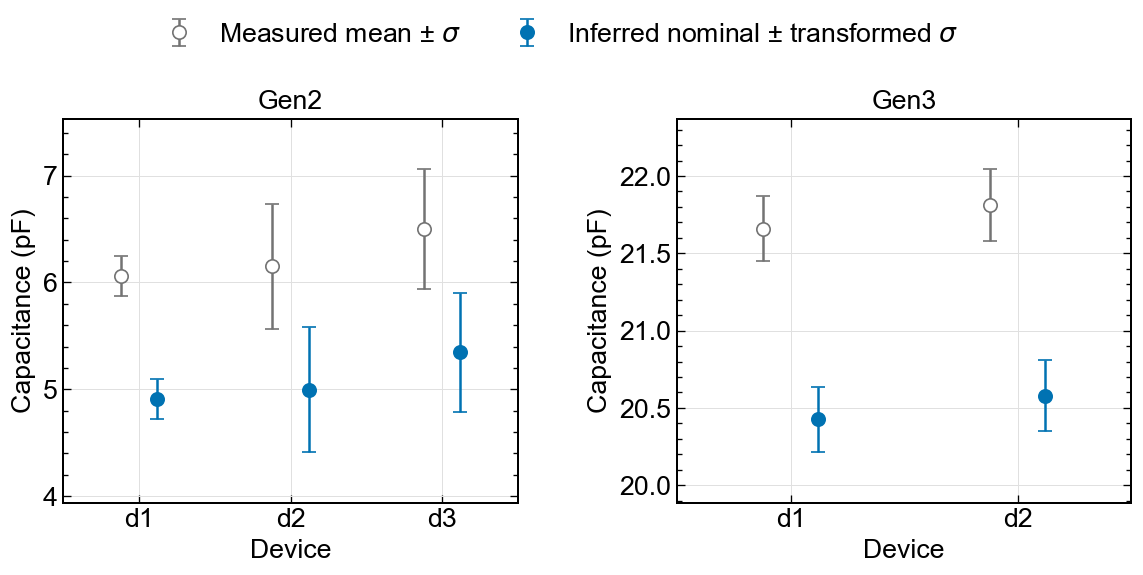

In [36]:
from matplotlib.ticker import AutoMinorLocator

fig_devices, axes = plt.subplots(1, 2, figsize=(10, 5))
fig_devices.subplots_adjust(left=0.09, right=0.98, bottom=0.16, top=0.80, wspace=0.35)
for ax, generation in zip(axes, ("Gen2", "Gen3")):
    data = device_summary.loc[device_summary.index.str.startswith(generation)]
    x = np.arange(len(data))
    ax.errorbar(x - 0.12, data["Measured mean (pF)"], yerr=data["Measured SD (pF)"],
                fmt="o", color="0.45", markerfacecolor="white", markersize=8,
                capsize=4, elinewidth=1.5, label="Measured mean ± $\sigma$")
    ax.errorbar(x + 0.12, data["Inferred nominal (pF)"], yerr=data["Transformed SD (pF)"],
                fmt="o", color="#0072B2", markersize=8, capsize=4, elinewidth=1.5,
                label="Inferred nominal ± transformed $\sigma$")
    ax.set(title=generation, xlabel="Device", ylabel="Capacitance (pF)",
           xticks=x, xticklabels=[name.split()[1] for name in data.index],
           xlim=(-0.5, len(data) - 0.5))
    ax.margins(y=0.18)
    ax.yaxis.set_major_locator(plt.MaxNLocator(5, steps=[1, 2, 2.5, 5, 10]))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))  # Device labels are categorical.

handles, labels = axes[0].get_legend_handles_labels()
fig_devices.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.0),
                   ncol=2, frameon=False, columnspacing=1.5, handletextpad=0.5)
plt.show()

# Capacitance calibration — round two

All supplied values are already averaged and are used directly, in **pF**.
Fit a separate, equally weighted linear calibration to the round-two references,
then invert it for Gen2 and Gen3. No repeat-level scatter was supplied, so these
plots show points without error bars. The styling matches round one, and figures
are displayed inline only.

In [37]:
round_two_calibration_slope, round_two_calibration_offset = np.polyfit(
    round_two_nominal_cap, round_two_measured_cap, 1
)
round_two_calibration_fit = (
    round_two_calibration_slope * round_two_nominal_cap + round_two_calibration_offset
)
round_two_calibration_r2 = 1 - np.sum((round_two_measured_cap - round_two_calibration_fit)**2) / np.sum(
    (round_two_measured_cap - round_two_measured_cap.mean())**2
)

round_two_calibration_summary = pd.DataFrame({
    "Nominal (pF)": round_two_nominal_cap,
    "Measured mean (pF)": round_two_measured_cap,
})
display(round_two_calibration_summary.style.hide(axis="index").format(precision=3))
print(f"Measured = {round_two_calibration_slope:.6f} × nominal {round_two_calibration_offset:+.6f} pF")
print(f"R² = {round_two_calibration_r2:.6f}")

Nominal (pF),Measured mean (pF)
4.700,4.670
10.000,9.940
15.000,15.510
18.000,18.640
24.000,24.620


Measured = 1.042107 × nominal -0.267819 pF
R² = 0.999554


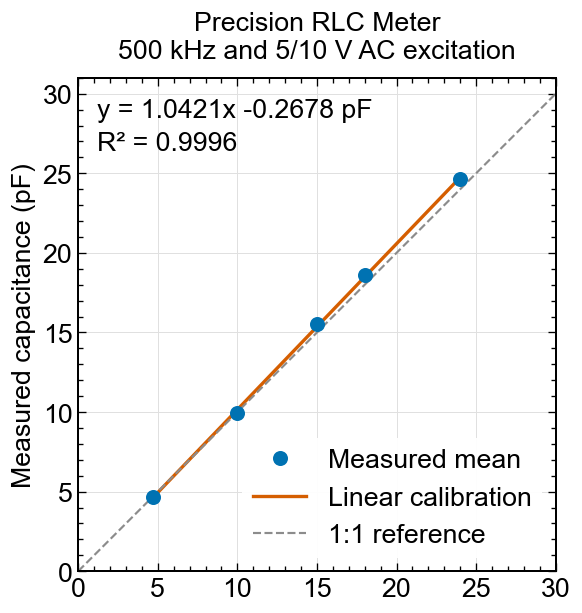

In [41]:
from matplotlib.ticker import AutoMinorLocator

fig_round_two_calibration, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)
round_two_reference_x = np.linspace(round_two_nominal_cap.min(), round_two_nominal_cap.max(), 200)
ax.plot(round_two_nominal_cap, round_two_measured_cap, "o", color="#0072B2",
        markersize=8, label="Measured mean", zorder=3)
ax.plot(round_two_reference_x,
        round_two_calibration_slope * round_two_reference_x + round_two_calibration_offset,
        color="#D55E00", linewidth=2, label="Linear calibration")
ax.plot([0, 30], [0, 30], "--", color="0.55", linewidth=1.3, label="1:1 reference")
ax.set(ylabel="Measured capacitance (pF)", xlim=(0, 30), ylim=(0, 31),
       xticks=np.arange(0, 31, 5), yticks=np.arange(0, 31, 5))
ax.set_title("Precision RLC Meter\n500 kHz and 5/10 V AC excitation", pad=12)
ax.set_aspect("equal", adjustable="box")
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))
ax.text(0.04, 0.96,
        f"y = {round_two_calibration_slope:.4f}x {round_two_calibration_offset:+.4f} pF\n"
        f"R² = {round_two_calibration_r2:.4f}",
        transform=ax.transAxes, va="top", linespacing=1.5)
ax.legend(loc="lower right", frameon=True, facecolor="white",
          edgecolor="none", framealpha=0.95)
plt.show()

## Inferred device capacitances — round two

The supplied Gen2 and Gen3 means are converted using
$C_\mathrm{nominal} = (C_\mathrm{measured} - b_2)/m_2$.
Gen2 is below the lowest reference and its nominal estimate is **extrapolated**;
Gen3 is within the calibrated range. Separate y-axis ranges show each generation.

In [39]:
round_two_device_summary = pd.DataFrame({
    "Generation": ["Gen2", "Gen3"],
    "Measured mean (pF)": [round_two_gen2.item(), round_two_gen3.item()],
}).set_index("Generation")
round_two_device_summary["Inferred nominal (pF)"] = (
    round_two_device_summary["Measured mean (pF)"] - round_two_calibration_offset
) / round_two_calibration_slope
round_two_device_summary["Calibration range"] = np.where(
    round_two_device_summary["Inferred nominal (pF)"].between(
        round_two_nominal_cap.min(), round_two_nominal_cap.max()
    ), "Within range", "Extrapolated"
)
round_two_gen2_nominal = round_two_device_summary.loc["Gen2", "Inferred nominal (pF)"]
round_two_gen3_nominal = round_two_device_summary.loc["Gen3", "Inferred nominal (pF)"]

display(round_two_device_summary.style.format(precision=3))

,Measured mean (pF),Inferred nominal (pF),Calibration range
Generation,,,
Gen2,3.720,3.827,Extrapolated
Gen3,20.440,19.871,Within range


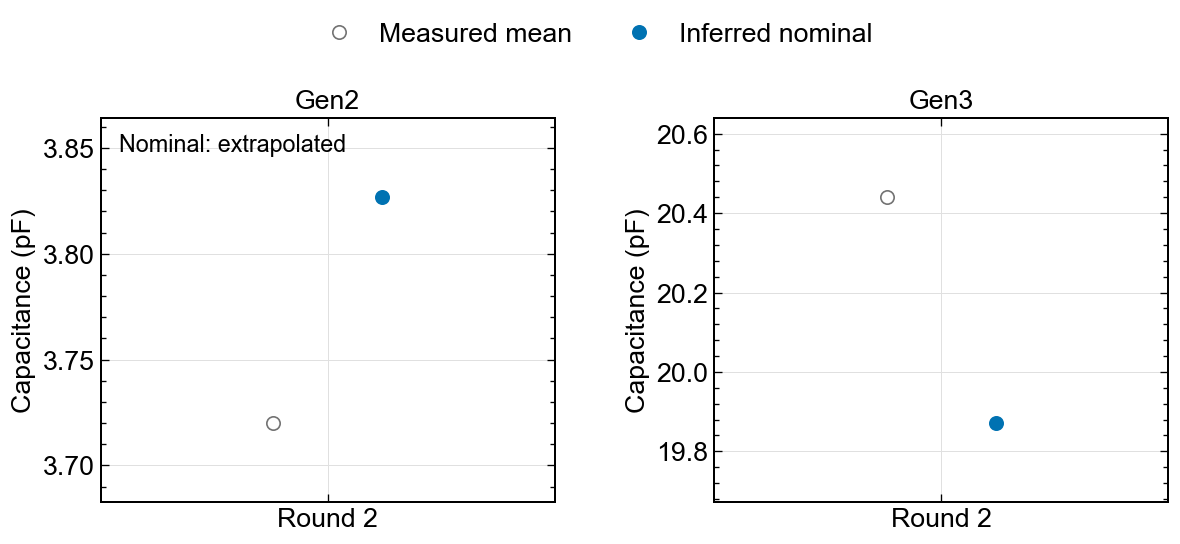

In [40]:
from matplotlib.ticker import AutoMinorLocator

fig_round_two_devices, axes = plt.subplots(1, 2, figsize=(10, 5))
fig_round_two_devices.subplots_adjust(left=0.09, right=0.98, bottom=0.16, top=0.80, wspace=0.35)
for ax, generation in zip(axes, ("Gen2", "Gen3")):
    row = round_two_device_summary.loc[generation]
    ax.plot(-0.12, row["Measured mean (pF)"], "o", color="0.45",
            markerfacecolor="white", markersize=8, label="Measured mean")
    ax.plot(0.12, row["Inferred nominal (pF)"], "o", color="#0072B2",
            markersize=8, label="Inferred nominal")
    ax.set(title=generation, ylabel="Capacitance (pF)", xticks=[0],
           xticklabels=["Round 2"], xlim=(-0.5, 0.5))
    ax.margins(y=0.35)
    ax.yaxis.set_major_locator(plt.MaxNLocator(5, steps=[1, 2, 2.5, 5, 10]))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax.ticklabel_format(axis="y", useOffset=False)
    if row["Calibration range"] == "Extrapolated":
        ax.text(0.04, 0.96, "Nominal: extrapolated", transform=ax.transAxes, va="top", fontsize=14)

handles, labels = axes[0].get_legend_handles_labels()
fig_round_two_devices.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.0),
                             ncol=2, frameon=False, columnspacing=1.5, handletextpad=0.5)
plt.show()